# POC — aligned prototypes

POC_01 §7b showed decoded month prototypes as flat lines. A month prototype averages ~6
windows whose starts alternate between two times of day 12 h apart, so the daily cycle
cancels before the prototype exists. This notebook tests one fix: **key the average by the
window's calendar position** (client-side, public calendar, unchanged server protocol).
Everything substantive lives in `fedwater_lab/aligned.py`.

| § | question |
|---|---|
| 2 | does the key partition the windows sensibly (coverage, contract checks)? |
| 3 | what does each average keep, per period? |
| 4 | is calendar position the dominant factor of the latent within a block? |
| 5 | does the decoded aligned prototype carry the waveform the month prototype lost? |
| 6 | does the server path (FINCH per key) keep it? |
| 7 | which geometry / key to adopt (**retrains** new geometries) |

## 0. Setup

In [1]:
import sys, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "fedwater").is_dir()), None)
assert REPO is not None, "run this from inside the fedwater repo"
LAB_DIR = REPO / "notebooks" / "fedwater_lab_refactor"
for p in (REPO / "src", LAB_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from fedwater_lab.worlds import load_world, list_worlds, pick_world
from fedwater_lab.store import Store
from fedwater_lab.specs import POC, Geometry
from fedwater_lab import data as D, recon as RC, aligned as AL

EXPERIMENTS = REPO / "data" / "09_experiments"
pd.set_option("display.width", 200, "display.max_columns", 40)

## 1. World and cell

Same world and selection as POC_01, so §5 reads the run POC_01 trained (a cache read).

In [2]:
FILTERS = dict(sim_hash="ece8f4ad92e5", placement_source="dynamic")
world = load_world(pick_world(EXPERIMENTS, **FILTERS))
store = Store(LAB_DIR / "lab_sandbox")

SELECTION = dict(kinds=("flow",), classes=("pure", "mixed"), include=(), exclude=())
spec = POC.with_(**SELECTION)
print(world.summary()[["tag", "n_months", "warmup_months", "first_switch",
                       "last_switch", "init_months", "final_months"]].to_string())
print(f"geometry {spec.geometry.label()}  "
      f"(window {spec.geometry.window_hours} h, whole days: {spec.geometry.whole_days})")

tag              District_A__LR_LR_LR_LR__baseline
n_months                                        65
warmup_months                                   12
first_switch                                    12
last_switch                                     63
init_months                                  0..11
final_months                                64..64
geometry a3w84s12  (window 252 h, whole days: False)


## 2. The key

For window $w$ with start $t_w$ (hours):

$$\mathrm{cycle\_pos}(w) = \left\lfloor \frac{t_w \bmod P}{b} \right\rfloor b$$

with period $P$ (`period_h`) and bin $b$ (`bin_h`, default: every distinct position). A
**block** is `block` consecutive months inside one world phase, or the whole phase
(`block="phase"`); blocks never cross init / transition / final. A **group** $g$ is
(block, cycle_pos), with the same id in every client. The artifact is

$$p_{c,g} = \frac{1}{n_{c,g}} \sum_{w \in g} z_w$$

over the final-model latents (`latent_trajectories`). Its size-weighted mean over a block's
groups is the block prototype, and with `block=1` that is exactly the run's
`post_fedavg_full` prototype. `check` asserts both.

Sources, per (client, group), all compared with the aligned reference $T_{c,g}$:

| source | object | federated? |
|---|---|---|
| `true` | $T_{c,g}$, the mean window over $g$ | reference |
| `aligned` | $\mathrm{dec}(p_{c,g})$ | yes |
| `ceiling` | $\frac{1}{n}\sum_{w\in g}\mathrm{dec}(z_w)$ | no. Decode-then-average: a reference for what the latent space carries, not a strict bound |
| `pooled` | $\mathrm{dec}(p_{c,\mathrm{block}})$, today's prototype | yes |
| `ref_pooled` | $T_{c,\mathrm{block}}$, today's reference | reference |
| `finch_aligned` | decoded FINCH centroid of $p_{c,g}$ (§6) | yes |

`coverage`: `n_min` is the fewest windows any client has in the group. `n_min = 1` means the
group prototype is one window, so it no longer summarises anything.

In [3]:
ALIGN = AL.Alignment(period_h=24, bin_h=None, block=1)     # time-of-day key, per month

OUT = AL.analyse(world, spec, ALIGN, store=store)
run = OUT["run"]
channels = RC.channel_table(world, OUT["fw"])
print(f"run_key {OUT['res'].get('run_key')}  cache_hit={OUT['res'].get('cache_hit')}  "
      f"alignment {ALIGN.label()}")
display(OUT["checks"])
assert OUT["checks"]["passed"].all()
cov = OUT["coverage"]
display(cov.groupby(["phase", "cycle"])[["n_min", "n_max"]]
          .agg(["min", "median", "max"]).reindex(RC.PERIODS, level=0))

run_key 3675c1f38427  cache_hit=True  alignment P24_B1


,check,value,passed
0,pooled == weighted mean of aligned,0.0,True
1,every window keyed,1548,True
2,block=1 pooled == post_fedavg_full,0.0,True
3,cycle positions per block (min..max),2..2,True


n_min            n_max           
                   min median max   min median max
phase      cycle                                  
init       00h       3    3.0   3     3    3.0   3
           12h       2    3.0   3     2    3.0   3
transition 00h       3    3.0   3     3    3.0   3
           12h       3    3.0   3     3    3.0   3
final      00h       2    2.0   2     2    2.0   2
           12h       2    2.0   2     2    2.0   2

## 3. What each average keeps

Averaging views that start at $t_w$ multiplies a component of period $P$ by

$$H(P) = \left|\frac{1}{n}\sum_w e^{2\pi i\, t_w / P}\right|$$

The `pooled` bars use the set a block prototype averages. The `aligned` bars use the sets the
group prototypes average (size-weighted over a block's groups). A bar at 0 means that period
is cancelled before any model is involved.

The sector signatures do not all sit at the same period. A residential morning/evening double
peak about 12 h apart is mostly the 12 h harmonic, so it survives the pooled mean. A
commercial or industrial day block is mostly the 24 h fundamental, so it does not.

period_h,8,12,24,84,168
scope,,,,,
aligned,1.0,1.0,1.0,0.749,0.267
pooled,0.0,1.0,0.0,0.167,0.209


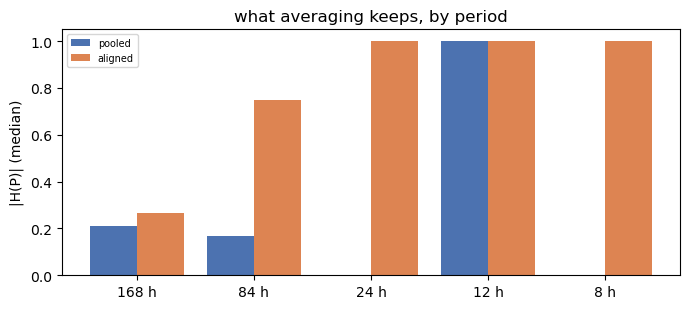

In [4]:
comb = OUT["comb"]
display(comb.groupby(["scope", "period_h"])["gain"].median().unstack().round(3))
fig, ax = plt.subplots(figsize=(7, 3.2))
AL.plot_comb(ax, comb)
fig.tight_layout()
plt.show()

## 4. Is calendar position the latent's dominant factor?

Per (client, block), over the 60-d latents:

$$\eta^2 = \frac{\sum_k n_k \lVert \bar z_k - \bar z\rVert^2}{\sum_w \lVert z_w - \bar z\rVert^2}$$

This is the share of the block's latent spread that cycle_pos explains. If the labels were
shuffled with the class sizes held fixed, its expectation would be
$\mathrm{chance} = (K-1)/(n-1)$ (0.2 for 2 classes of 3), and `lift` $= \eta^2 -$ chance.

Per-block `p` is a seeded permutation p-value, but one block has almost no power. The pooled
test is therefore the one to read: it compares the mean $\eta^2$ over blocks against the same
mean with labels shuffled in every block at once.

With `a3w84s12` a periodic pattern in $\eta^2$ over blocks is expected. A 14-day month
(336 h) is not a multiple of the 36 h stride (336 mod 36 = 12 h), so the window grid shifts
12 h relative to the month start each month and repeats every 3 months. The class sizes and
positions therefore change with that period.

Reading: a clear lift means the month mean averages over the latent's main within-month
factor, and the key removes it. A lift near 0 means the latent does not separate the
positions, so §5 has to show whether the decoder does.

,client,phase,blocks,eta2,chance,lift,p
0,all,all,260,0.479,0.203,0.276,0.005
1,all,final,4,0.552,0.333,0.218,0.030
2,all,init,48,0.645,0.204,0.441,0.005
3,all,transition,208,0.439,0.200,0.239,0.005


phase,init,transition,final
client,,,
District_A,0.403,0.226,-0.034
District_B,0.511,0.230,0.291
District_C,0.616,0.259,0.397
District_D,0.234,0.242,0.218


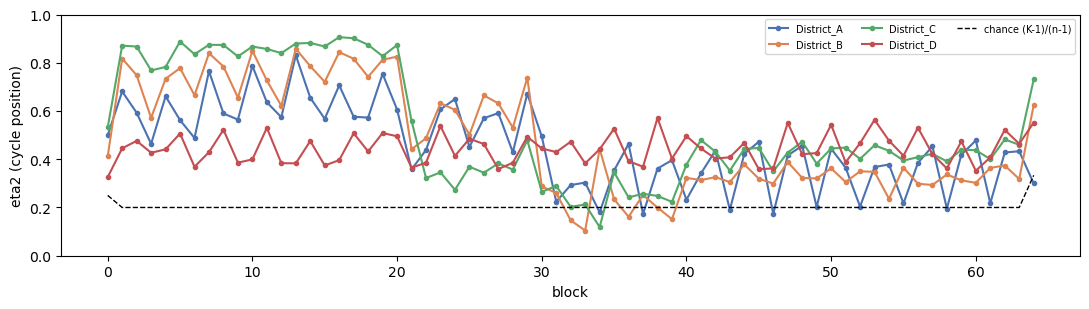

In [5]:
per, pooled = OUT["eta"], OUT["eta_pooled"]
if not len(per):
    print("one cycle position per block: nothing to separate (expected with a 24 h stride "
          "and a time-of-day key)")
else:
    display(pooled[pooled["client"] == "all"].round(3))
    display(pooled[pooled["client"] != "all"]
            .pivot_table(index="client", columns="phase", values="lift")
            .reindex(columns=[p for p in RC.PERIODS if p in set(pooled["phase"])]).round(3))
    fig, ax = plt.subplots(figsize=(11, 3.2))
    AL.plot_eta2(ax, per)
    fig.tight_layout()
    plt.show()

## 5. The ladder

**Model quality first.** Each window's own reconstruction is scored before any averaging:
`window_rmse` $=\sqrt{\mathrm{mean}_{w,t,i}(\mathrm{dec}(z_w)-x_w)^2}$,
`window_amp` $=\mathrm{median}_{w,i}\ \sigma_t(\mathrm{dec}(z_w)_i)/\sigma_t(x_{wi})$, and
`window_r` $=\mathrm{median}_{w,i}\ \mathrm{corr}_t(\mathrm{dec}(z_w)_i, x_{wi})$. If single
windows already decode flat (`window_amp` near 0), the bottleneck is the AER and no key can
help.

**Then the sources**, per (client, group, channel $i$), with $X$ the source's window:

* `rmse` $=\sqrt{\mathrm{mean}_t (X_{ti}-T_{ti})^2}$: distance to the aligned reference.
* `r_shape` $=\mathrm{corr}_t(X_i, T_i)$: waveform agreement, independent of level.
* `amp` $=\sigma_t(X_i)/\sigma_t(T_i)$: amplitude retention. 0 is the flat line of POC_01
  §7b; 1 is the reference's swing.
* `r2_dem` $=\mathrm{corr}_t(X_i, D_{c,i})^2$: does the window look like its own district's
  demand, cut at the same starts. The `true` row is the ceiling the data allows.

**Decision:**
* `aligned` $\gg$ `pooled` and `aligned` at or above `ceiling`: the key is the fix.
  (`aligned` can exceed `ceiling`, because averaging decoded windows smooths too.)
* `aligned` $\ll$ `ceiling`: the latent carries more than one mode per group, so cluster
  windows client-side instead.
* `ceiling` itself flat: see model quality above.

,window_rmse,window_amp,window_r
phase,,,
init,0.627,0.026,0.004
transition,0.617,0.029,-0.002
final,0.618,0.032,0.038


,source,phase,rmse,r_shape,amp,r2_dem,n
0,true,init,0.000,1.000,1.000,0.732,384
1,true,transition,0.000,1.000,1.000,0.753,1664
2,true,final,0.000,1.000,1.000,0.733,32
3,aligned,init,0.593,0.002,0.026,0.006,384
4,aligned,transition,0.555,0.005,0.031,0.008,1664
5,aligned,final,0.568,0.021,0.032,0.009,32
6,ceiling,init,0.593,0.002,0.026,0.006,384
7,ceiling,transition,0.555,0.005,0.031,0.008,1664
8,ceiling,final,0.568,0.025,0.032,0.008,32
9,pooled,init,0.593,0.004,0.026,0.006,384


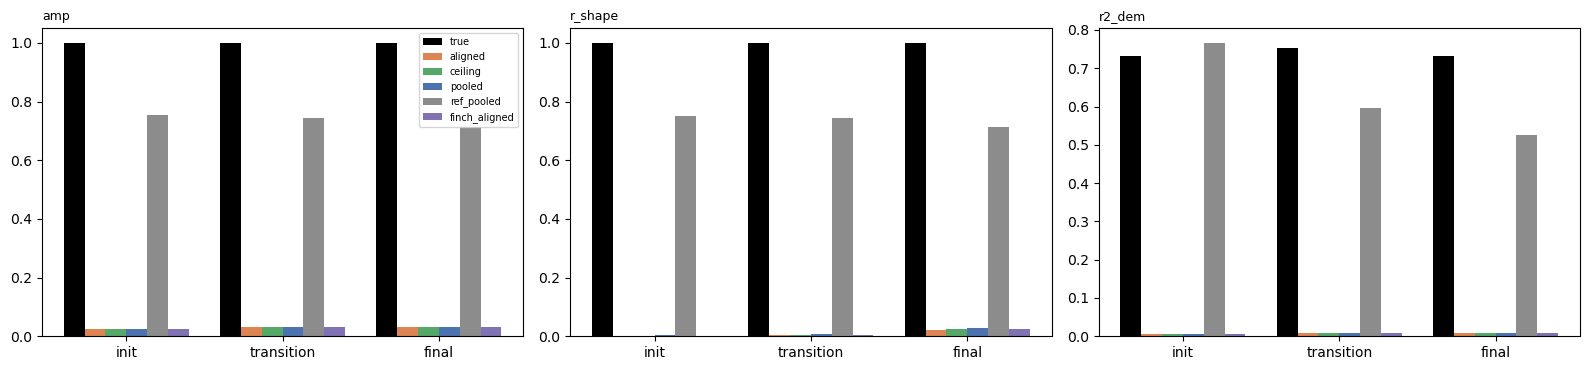

,all,init,final
geometry,a3w84s12,a3w84s12,a3w84s12
align,P24_B1,P24_B1,P24_B1
win/group (median),3.0,3.0,3.0
window_amp,0.028651,0.025784,0.031578
window_r,0.00011,0.00409,0.037602
eta2_lift,0.276341,0.441015,0.218344
eta2_p,0.005,0.005,0.03
H24_pooled,0.0,0.0,0.0
H24_aligned,1.0,1.0,1.0
H168_pooled,0.208993,0.208993,0.173974


In [6]:
wq = run.window_rmse
display(wq.groupby("phase")[["window_rmse", "window_amp", "window_r"]].mean()
          .reindex([p for p in RC.PERIODS if p in set(wq["phase"])]).round(3))

summ = OUT["summary"]
display(summ.round(3))
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
AL.plot_ladder_summary(ax, summ)
fig.tight_layout()
plt.show()

display(pd.DataFrame({p or "all": AL.headline(OUT, p)
                      for p in (None, "init", "final")}).round(3))

### 5a. Browser

`period = block` shows one block at one cycle position, or every position as small
multiples. `init / transition / final` averages each source over that phase's groups at each
position. The dotted red line is the own-district demand shape, drawn on the true window's
scale with the sign of its correlation (display only). The table under the plot shows §5's
metrics for exactly that selection.

In [ ]:
_ = AL.aligned_browser(run, OUT["fid"], channels)

## 6. Server side

The upstream `aggregate_prototypes` is called unchanged, with the group id as the key in
place of the month. `finch_aligned` (in §5's tables) is the decoded centroid each client's
aligned prototype falls in, found by nearest cosine as in POC_01 §7c. If there is 1 cluster
per group at cos ≈ 1, the server averages clients together. That is harmless for the
waveform while every client shares a regime, but it will average regimes away once they
differ.

In [8]:
mem = run.server["membership"]
display(mem.groupby("phase")
           .agg(groups=("gid", "nunique"), clusters_mean=("n_clusters", "mean"),
                cos_min=("cos", "min"), cos_mean=("cos", "mean"))
           .reindex([p for p in RC.PERIODS if p in set(mem["phase"])]).round(3))

,groups,clusters_mean,cos_min,cos_mean
phase,,,,
init,24,1.542,0.934,0.979
transition,104,1.087,0.833,0.949
final,2,1.000,0.865,0.930


## 7. Geometry and key

Stride decides which times of day a month mean mixes: $H(24\,\mathrm{h}) = 1$ requires the
stride to be a multiple of 24 h. Window length decides whether a window is a whole number of
days (`a3w84` is 10.5 d; the original `a2w84` was exactly 7 d). The weekly cycle needs a
weekday key (`period_h=168, bin_h=24`). With about 1.3 windows per (month, weekday) that key
is too thin per month, so the candidates below pool per phase.

**Any geometry not already in the store trains here.** Set `RUN_GEOMETRY = True`
deliberately.

Two things to keep in mind when reading the table:
* **Blocks are coarser.** `block="phase"` trades time resolution for calendar resolution.
  Month prototypes stay the drift artifact; phase × position prototypes are the shape
  artifact.
* **The `final` stretch is short.** This world's `final` is one month, so the `final` column
  rests on very few groups.

In [9]:
RUN_GEOMETRY = False

CANDIDATES = [
    (spec,                                                  AL.Alignment(None, None, 1)),
    (spec,                                                  AL.Alignment(24, None, 1)),
    (spec.with_(geometry=Geometry(interval_agg_h=3, window_size=84, step_size=8)),
                                                            AL.Alignment(None, None, 1)),
    (spec.with_(geometry=Geometry(interval_agg_h=3, window_size=84, step_size=8)),
                                                            AL.Alignment(168, 24, "phase")),
    (spec.with_(geometry=Geometry(interval_agg_h=3, window_size=56, step_size=8)),
                                                            AL.Alignment(168, 24, "phase")),
]

if RUN_GEOMETRY:
    rows, outs = {}, {}
    for i, (sp, al) in enumerate(CANDIDATES):
        o = AL.analyse(world, sp, al, store=store, server=False)
        assert o["checks"]["passed"].all(), o["checks"]
        outs[i] = o
        for ph in ("init", "final"):
            rows[(i, ph)] = AL.headline(o, ph)
    COMPARE = pd.DataFrame(rows)
    COMPARE.columns.names = ["candidate", "phase"]
    display(COMPARE.round(3))

## 8. Model sanity: why every source decodes flat

§5 gave `window_amp` ≈ 0.03 and `window_r` ≈ 0: single windows already decode flat, so the
averaging key cannot be the cause. The three checks below read existing artifacts only (no
training) and separate three candidate causes: **undertraining**, **a level-only decoder**,
and **latent compression by the prototype loss**. They also add the untrained control §4
lacked.

### 8a. Loss: still learning, and better than a flat line?

`loss_by_round` is `training_log` averaged per round. `d_mse` is the relative change of
`loss_mse` from the previous round, and `proto_share` $=$ `loss_proto` / `loss`.

`loss_baselines` scores the final model and two flat predictors with the AER's own loss,
$\frac{r}{2}\mathrm{MSE}(ry) + (1-r)\,\mathrm{MSE}(y) + \frac{r}{2}\mathrm{MSE}(fy)$ with
$r =$ `reg_ratio`:

* `base_const`: each channel's client-wide mean at every step. This needs no latent at all.
* `base_wmean`: each window's own input mean (steps $1..W-2$) at every step. This is the best
  flat line a latent could encode.

How to read them:

* **Undertrained:** `d_mse` still clearly negative at the last round, and
  `final_over_wmean` near 1.
* **Converged, but only to the window level:** `d_mse` ≈ 0 and `final_over_wmean` ≈ 1. The
  cause is then capacity or objective, not the number of steps.
* **Captures shape:** `final_over_wmean` well below 1. That would contradict §5, so check the
  decode path.

A large `proto_share` means most of the gradient served the prototype term, not the
reconstruction.

In [10]:
cfg = OUT["fl"]
print("training:", {k: cfg["training"][k] for k in
                    ("rounds", "local_epochs", "learning_rate", "batch_size",
                     "proto_alpha", "infonce_temperature")},
      "| reg_ratio:", cfg["model"]["reg_ratio"])
print("windows/client:", {c: len(d["windows"]) for c, d in OUT["fw"].items()})
display(AL.loss_by_round(OUT["res"]).round(4))
display(AL.loss_baselines(run, OUT["fw"], OUT["fl"]).round(4))

training: {'rounds': 5, 'local_epochs': 1, 'learning_rate': 0.001, 'batch_size': 64, 'proto_alpha': 0.2, 'infonce_temperature': 0.02} | reg_ratio: 0.5
windows/client: {'District_A': 387, 'District_B': 387, 'District_C': 387, 'District_D': 387}


,round,loss,loss_mse,loss_proto,d_mse,proto_share
0,0,0.3956,0.3956,0.0000,NaN,0.0000
1,1,1.2474,0.3901,0.8573,-0.0138,0.6872
2,2,1.2239,0.3814,0.8425,-0.0224,0.6884
3,3,1.1947,0.3736,0.8211,-0.0205,0.6873
4,4,1.1822,0.3658,0.8164,-0.0207,0.6905


,client,n,loss_final,base_const,base_wmean,final_over_const,final_over_wmean
0,District_A,387,0.4390,0.4460,0.2646,0.9843,1.6593
1,District_B,387,0.3642,0.2947,0.2936,1.2359,1.2402
2,District_C,387,0.4025,0.3282,0.3142,1.2263,1.2809
3,District_D,387,0.3554,0.3300,0.3299,1.0771,1.0772


### 8b. Level-only decoder?

Per (client, phase, channel), over windows $w$, where $\bar x_w$ is the window's mean over
steps:

* `level_r` $=\mathrm{corr}_w(\overline{\mathrm{dec}}_w, \bar x_w)$
* `level_ratio` $=\sigma_w(\overline{\mathrm{dec}}_w)/\sigma_w(\bar x_w)$
* `shape_amp` $=\mathrm{median}_w\ \sigma_t(\mathrm{dec}_w)/\sigma_t(x_w)$

`level_r` near 1 with `shape_amp` near 0 means the decoder reads the window's level from the
latent and nothing else. That is what a flat-line minimum of the loss looks like. Both near 0
means the decoder ignores the latent entirely.

In [11]:
DL = AL.decoder_levels(run, OUT["fw"])
display(DL.groupby(["phase"])[["level_r", "level_ratio", "shape_amp"]].mean()
          .reindex([p for p in RC.PERIODS if p in set(DL["phase"])]).round(3))
display(DL.groupby(["client"])[["level_r", "level_ratio", "shape_amp"]].mean().round(3))

,level_r,level_ratio,shape_amp
phase,,,
init,0.343,0.553,0.025
transition,0.333,0.360,0.028
final,0.529,0.553,0.029


,level_r,level_ratio,shape_amp
client,,,
District_A,0.468,0.449,0.033
District_B,0.219,0.483,0.027
District_C,0.361,0.537,0.025
District_D,0.560,0.486,0.025


### 8c. Is the calendar-position signal learned? Is the latent compressed?

`eta2_by_round` repeats §4's pooled test (client = all) on every snapshot round and stage,
using the same key. **Round −1 is the untrained initialisation shared by all clients: the
control.** If its lift matches the final one, the latent's separation of start times is
inherited from the input through a random encoder, not learned. Snapshot rounds use the
month-stratified subset (about 5 windows per month), so their chance level differs from the
`final_all` row. Compare `lift`, not raw $\eta^2$.

`spread_by_round` gives the absolute spread, as an RMS per latent dimension $d$:

* `norm` $=\sqrt{\overline{\lVert z_w\rVert^2}/d}$
* `s_block` $=\sqrt{\overline{\lVert z_w-\bar z_{c,\mathrm{block}}\rVert^2}/d}$: what a month
  prototype averages over.
* `s_group`: the same around the (client, group) mean, i.e. what remains after the key.
* `rel_block` $=$ `s_block` / `norm`.

If `rel_block` falls over rounds while `norm` holds, training is pulling windows onto their
month mean. The prototype term's MSE-to-mean part (weight $1-\alpha$) does exactly that, and
the decoder is then handed nearly the same vector for every window of a month.

In [12]:
ETA_R = AL.eta2_by_round(world, OUT["res"], ALIGN, run=run, n_perm=99)
display(ETA_R.pivot_table(index=["round", "stage"], columns="phase",
                          values="lift", sort=False).round(3))
display(ETA_R[ETA_R["phase"] == "all"].round(3))

SPR = AL.spread_by_round(world, OUT["res"], ALIGN, run=run)
display(SPR.round(4))

phase              all  final   init  transition
round     stage                                 
-1        pre    0.275  0.223  0.440       0.238
0         pre    0.276  0.224  0.443       0.239
          post   0.275  0.223  0.441       0.238
2         pre    0.274  0.215  0.441       0.236
          post   0.275  0.224  0.443       0.237
4         pre    0.272  0.209  0.441       0.235
          post   0.273  0.218  0.441       0.235
final_all post   0.276  0.218  0.441       0.239

,round,stage,phase,blocks,eta2,chance,lift,p
0,-1,pre,all,260,0.526,0.251,0.275,0.01
4,0,post,all,260,0.526,0.251,0.275,0.01
8,0,pre,all,260,0.527,0.251,0.276,0.01
12,2,post,all,260,0.526,0.251,0.275,0.01
16,2,pre,all,260,0.525,0.251,0.274,0.01
20,4,post,all,260,0.524,0.251,0.273,0.01
24,4,pre,all,260,0.524,0.251,0.272,0.01
28,final_all,post,all,260,0.479,0.203,0.276,0.01


,round,stage,n,norm,s_client,s_block,s_group,rel_block
0,-1,pre,1296,0.0821,0.0335,0.0277,0.0189,0.3377
1,0,post,1296,0.0850,0.0337,0.0279,0.0189,0.3278
2,0,pre,1296,0.0881,0.0344,0.0282,0.0192,0.3201
3,2,post,1296,0.0906,0.0324,0.0267,0.0182,0.2946
4,2,pre,1296,0.0899,0.0325,0.0263,0.0180,0.2926
5,4,post,1296,0.0966,0.0317,0.0259,0.0177,0.2684
6,4,pre,1296,0.0963,0.0319,0.0257,0.0176,0.2671
7,final_all,post,1548,0.0966,0.0318,0.0265,0.0187,0.2747


### 8d. Reading

| 8a | 8b | 8c | cause | next |
|---|---|---|---|---|
| `d_mse` < 0 at the end, ratio ≈ 1 | level only | — | undertrained | longer training cell |
| `d_mse` ≈ 0, ratio ≈ 1 | level only | `rel_block` stable | capacity / architecture | decoder variant |
| `proto_share` high | level only | `rel_block` falling | prototype term compresses the latent | `proto_alpha` / reg weight axis |
| — | — | lift(−1) ≈ lift(final) | position signal inherited, not learned | report §4 against the control |

## What this leaves open

* **Reconstruction question, not regime question.** This world is `LR_LR_LR_LR`, so every
  district has the same shape before the drift. §5 tests whether prototypes carry the demand
  waveform at all. Whether they tell districts apart needs a mixed-sector map with a longer
  post-drift stretch; `recon.retrieval_table` then runs unchanged on these groups.
* **Reported, not trained.** The keyed prototype is computed after training. FPL's
  contrastive term still uses month keys, and training on group keys would change the loss.
* **Weekday origin.** Weekday numbers are $\lfloor t/24\rfloor \bmod 7$ from step 0, as
  `data.window_metadata` counts them. Whether step 0 is the demand model's weekday 0 is not
  checked here.